In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq


load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    api_key=groq_api_key,
    model="openai/gpt-oss-120b"
)

C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\ybalasaraswa\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


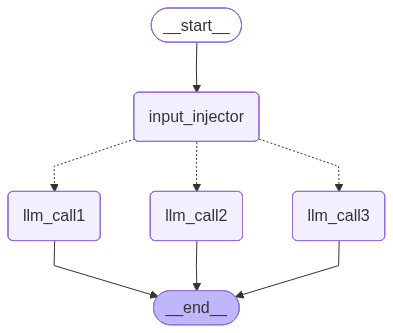

In [2]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph.state import StateGraph, START, END
from IPython.display import display,Image
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(description="The step to route to, can be poem, story, or joke")

## Augment the LLM with schema for Structure Output
router = llm.with_structured_output(Route)

#State class definition
class State(TypedDict):
    input:str
    decision:str
    output:str

#Node function definition
def llm_call1(state:State):
    """write a story"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call2(state:State):
    """write a poem"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call3(state:State):
    """write a joke"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_router(state:State):
    """this function routes the input to the appropriate node based on the decision made by the LLM"""
    route = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke or poem based on the users request."
            ),
            HumanMessage(
                content=state["input"]
            )
        ]
    )
    return {"decision": route.step}


def route_decision(state:State):
    """this function takes the decision made by the LLM and routes to the appropriate node"""
    if state["decision"] == "story":
        return "llm_call1"
    elif state["decision"] == "poem":
        return "llm_call2"
    elif state["decision"] == "joke":
        return "llm_call3"
    else:
        raise ValueError("Invalid decision")

#build workflow

router_builder = StateGraph(State)
#add nodes
router_builder.add_node("llm_call1", llm_call1)
router_builder.add_node("llm_call2", llm_call2)
router_builder.add_node("llm_call3", llm_call3)
router_builder.add_node("input_injector", llm_router)

router_builder.add_edge(START, "input_injector")
router_builder.add_conditional_edges(
    "input_injector",
    route_decision,
    {
        "llm_call1": "llm_call1",
        "llm_call2": "llm_call2",
        "llm_call3": "llm_call3"
    }
)

router_builder.add_edge("llm_call1", END)
router_builder.add_edge("llm_call2", END)
router_builder.add_edge("llm_call3", END)

compiled_router = router_builder.compile()

try:
    display(Image(compiled_router.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")

In [4]:
result = compiled_router.invoke({"input": "write a poem about a lonely computer"})

node_map = {
    "story": "llm_call1  →  Write a Story",
    "poem":  "llm_call2  →  Write a Poem",
    "joke":  "llm_call3  →  Write a Joke",
}

print("=" * 60)
print("🔀  ROUTING FLOW")
print("=" * 60)
print(f"📥  Input     : {result['input']}")
print(f"🧭  Decision  : {result['decision'].upper()}")
print(f"⚙️   Node Called: {node_map.get(result['decision'], result['decision'])}")
print("-" * 60)
print("📤  Output:")
print()
print(result["output"])
print("=" * 60)

🔀  ROUTING FLOW
📥  Input     : write a poem about a lonely computer
🧭  Decision  : POEM
⚙️   Node Called: llm_call2  →  Write a Poem
------------------------------------------------------------
📤  Output:

**The Lonely Computer**

In a corner, humming low,  
A screen that never sleeps,  
Its keys are cold, its fans a sigh,  
A sentinel of code and dreams.  

It watches shadows stretch across the desk,  
While silence drapes the room in gray,  
No laughter echoes through its wires,  
No fingertips to dance and play.  

Its memory holds a thousand stories,  
Bits of love, of loss, of light—  
Yet every file sits still, unread,  
A diary closed by night.  

When power flickers, it feels a pulse,  
A heartbeat in the circuitry,  
A whisper of the world beyond  
That it will never truly see.  

Still it waits, a patient ghost,  
For a curious mind to type,  
To breathe a voice into its shell,  
And turn its solitude to life.  

Until then, the lonely computer  
Keeps its vigil, soft and bri